Processing the LFW Dataset with a CNN  - 7/23/2026 - DAMHAR2570

### Load and Explore Dataset

Date: 2026-07-24

Student ID: DAMHAR2570

Loading LFW Dataset...
Dataset loaded. Classesfound: 7


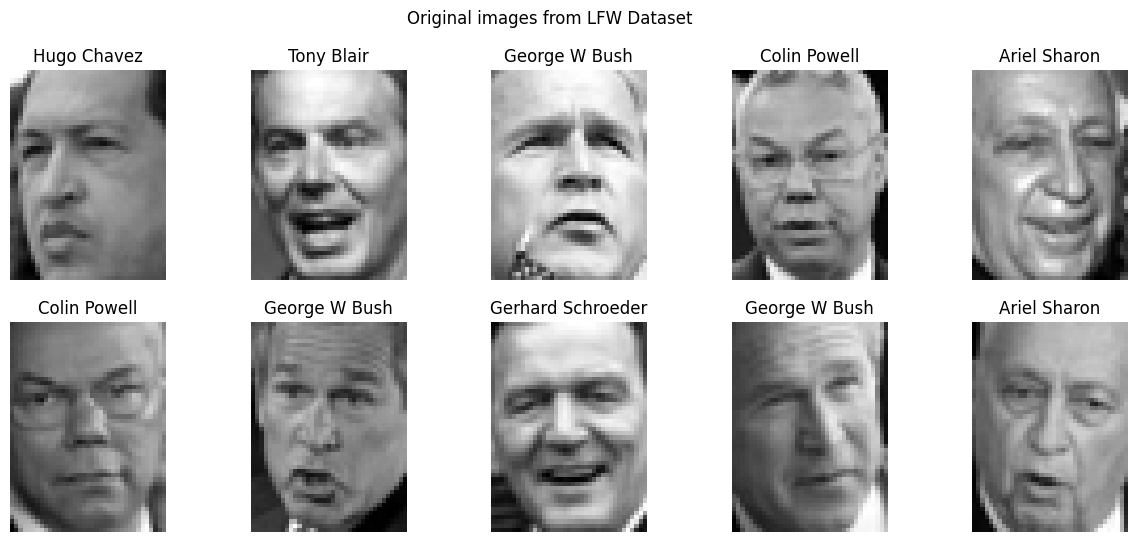

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

display(Markdown("### Load and Explore Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print("Loading LFW Dataset...")
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

X_original = lfw_people.data
y_original = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print(f"Dataset loaded. Classesfound: {n_classes}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(lfw_people.images[i], cmap='gray')
    ax.set_title(target_names[y_original[i]])
    ax.axis('off')
plt.suptitle("Original images from LFW Dataset")
plt.show()

In [2]:
display(Markdown("### Preprocessing the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

X_normalized = X_original / 255.0

min_vals = np.min(X_normalized, axis=1).reshape(-1, 1)
max_vals = np.max(X_normalized, axis=1).reshape(-1, 1)
X_engineered = np.hstack((X_normalized, min_vals, max_vals))

X_train, X_test, y_train, y_test = train_test_split(X_engineered, y_original, test_size=0.3, random_state=42)

y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

print("\n===Data Shapes===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"y_test_cat shape: {y_test_cat.shape}")

### Preprocessing the Data

Date: 2026-07-24

Student ID: DAMHAR2570


===Data Shapes===
X_train shape: (901, 1852)
X_test shape: (387, 1852)
y_train_cat shape: (901, 7)
y_test_cat shape: (387, 7)


In [3]:
display(Markdown("### Construct and Train CNN MLP Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

model_1 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n===Model 1 Summary===")
model_1.summary(),

print("\nTraining Model 1...")
history_1 = model_1.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_data=(X_test, y_test_cat), verbose=1)

### Construct and Train CNN MLP Model

Date: 2026-07-24

Student ID: DAMHAR2570


===Model 1 Summary===


C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         237,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 245,895 (960.53 KB)

 Trainable params: 245,895 (960.53 KB)

 Non-trainable params: 0 (0.00 B)


Training Model 1...
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.3446 - loss: 1.8936 - val_accuracy: 0.4289 - val_loss: 1.7038
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3895 - loss: 1.7228 - val_accuracy: 0.4289 - val_loss: 1.6631
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4175 - loss: 1.7152 - val_accuracy: 0.4289 - val_loss: 1.6670
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3971 - loss: 1.7183 - val_accuracy: 0.4289 - val_loss: 1.6531
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3891 - loss: 1.7431 - val_accuracy: 0.4289 - val_loss: 1.6541
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4267 - loss: 1.6998 - val_accuracy: 0.4289 - val_loss: 1.6574
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3898 - loss: 1.7061 - val_accuracy: 0.4289 - val_loss: 1.6459
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4209 - loss: 1.6862 - val

### Evaluate CNN Model

Date: 2026-07-24

Student ID: DAMHAR2570


Model 1 Testing Accuracy: 0.4806 | Testing Loss: 1.3788
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


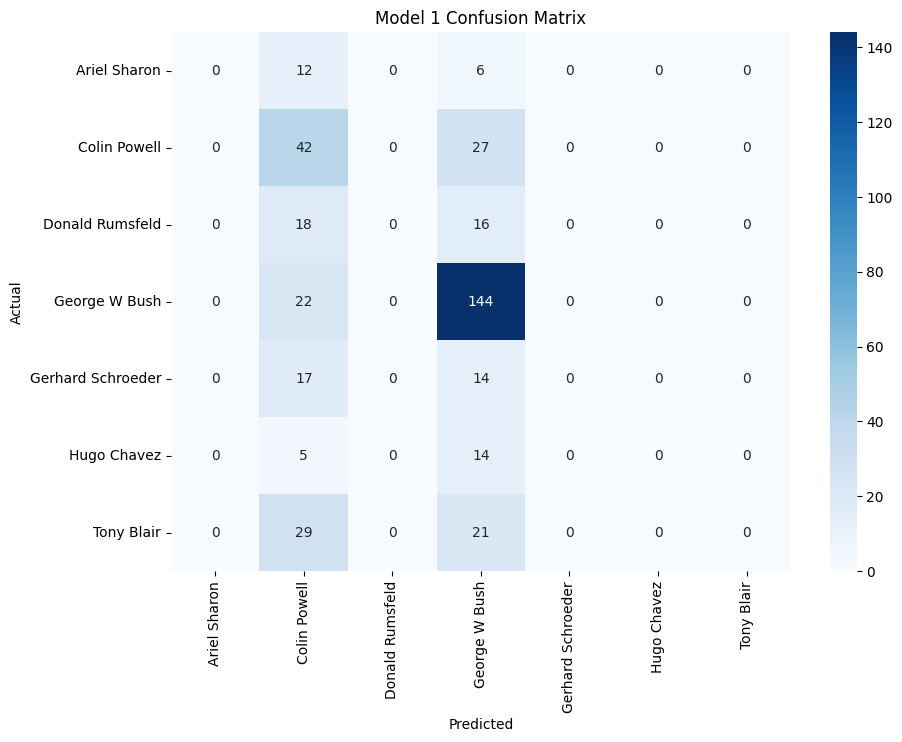

In [4]:
display(Markdown("### Evaluate CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

loss_1, acc_1 = model_1.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nModel 1 Testing Accuracy: {acc_1:.4f} | Testing Loss: {loss_1:.4f}")

y_pred_probs_1 = model_1.predict(X_test)
y_pred_classes_1 = np.argmax(y_pred_probs_1, axis=1)

cm_1 = confusion_matrix(y_test, y_pred_classes_1)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Model 1 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [5]:
display(Markdown("### Apply PCA for Model Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

pca = PCA(n_components=150, whiten=True, random_state=42)
X_pca = pca.fit_transform(X_normalized)

X_pca_engineered = np.hstack((X_pca, min_vals, max_vals))

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_engineered, y_original, test_size=0.3, random_state=42
)
y_train_pca_cat = to_categorical(y_train_pca, num_classes=n_classes)
y_test_pca_cat = to_categorical(y_test_pca, num_classes=n_classes)

model_2 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n===Adjusted Model PCA Summary===")
model_2.summary()

### Apply PCA for Model Tuning

Date: 2026-07-24

Student ID: DAMHAR2570


===Adjusted Model PCA Summary===


C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 256)                 │          39,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 72,967 (285.03 KB)

 Trainable params: 72,967 (285.03 KB)

 Non-trainable params: 0 (0.00 B)

### Evaluate the Adjusted CNN Model

Date: 2026-07-24

Student ID: DAMHAR2570


Training Adjusted Model PCA...
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.2355 - loss: 2.3120 - val_accuracy: 0.4367 - val_loss: 1.6151
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3533 - loss: 1.8094 - val_accuracy: 0.4625 - val_loss: 1.5067
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4416 - loss: 1.5336 - val_accuracy: 0.5039 - val_loss: 1.4124
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4995 - loss: 1.3837 - val_accuracy: 0.5711 - val_loss: 1.3135
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5389 - loss: 1.2836 - val_accuracy: 0.6021 - val_loss: 1.2110
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6377 - loss: 1.0313 - val_accuracy: 0.6563 - val_loss: 1.0737
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6526 - loss: 0.9957 - val_accuracy: 0.6977 - val_loss: 0.9554
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7383 - loss: 0.7624 -

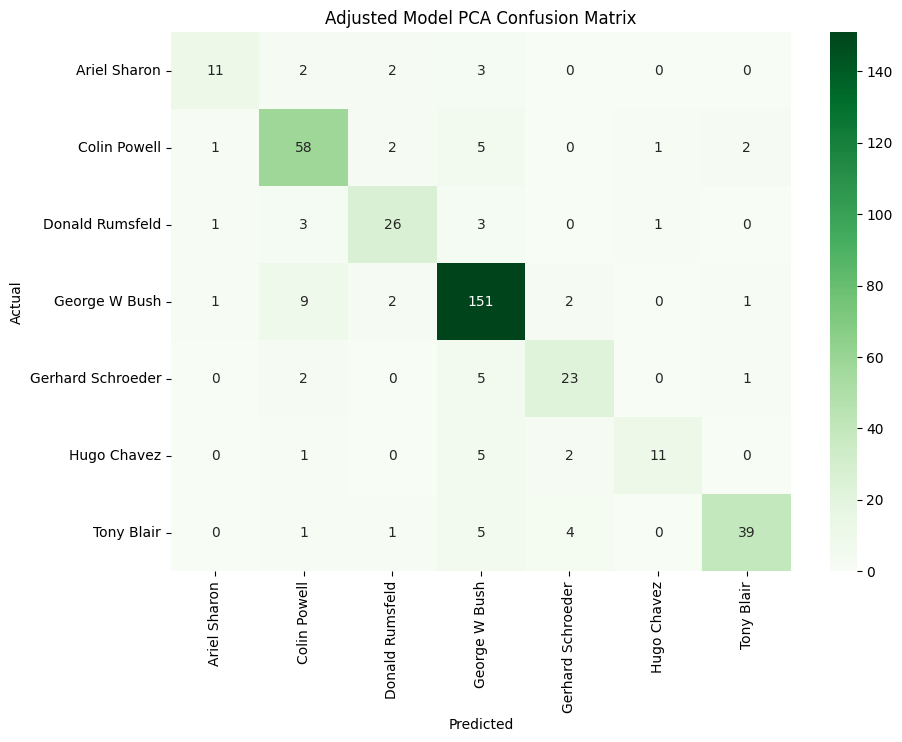

In [6]:
display(Markdown("### Evaluate the Adjusted CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print("\nTraining Adjusted Model PCA...")
history_2 = model_2.fit(X_train_pca, y_train_pca_cat, epochs=50, batch_size=32, validation_data=(X_test_pca, y_test_pca_cat), verbose=1)

y_pred_probs_2 = model_2.predict(X_test_pca)
y_pred_classes_2 = np.argmax(y_pred_probs_2, axis=1)

cm_2 = confusion_matrix(y_test_pca, y_pred_classes_2)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.title("Adjusted Model PCA Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Compare Performance and Models

Date: 2026-07-24

Student ID: DAMHAR2570

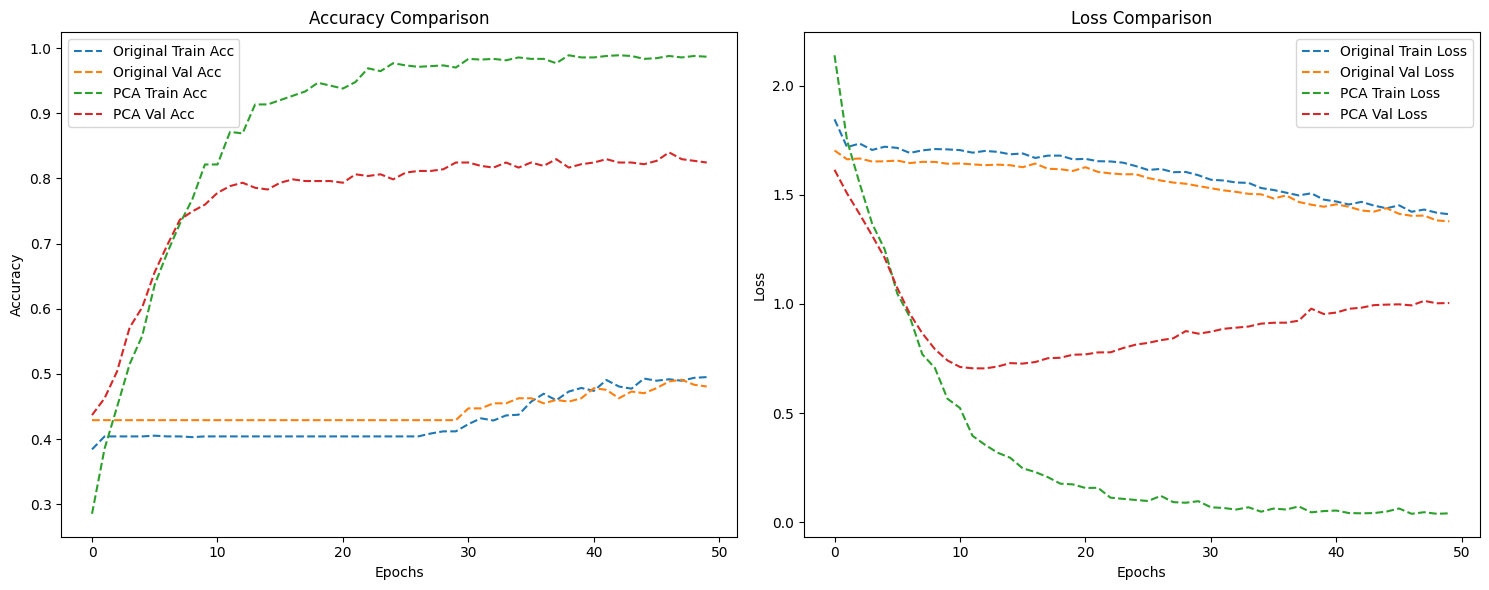

In [8]:
display(Markdown("### Compare Performance and Models"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(history_1.history['accuracy'], label='Original Train Acc', linestyle='--')
axes[0].plot(history_1.history['val_accuracy'], label='Original Val Acc', linestyle='--')
axes[0].plot(history_2.history['accuracy'], label='PCA Train Acc', linestyle='--')
axes[0].plot(history_2.history['val_accuracy'], label='PCA Val Acc', linestyle='--')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_1.history['loss'], label='Original Train Loss', linestyle='--')
axes[1].plot(history_1.history['val_loss'], label='Original Val Loss', linestyle='--')
axes[1].plot(history_2.history['loss'], label='PCA Train Loss', linestyle='--')
axes[1].plot(history_2.history['val_loss'], label='PCA Val Loss', linestyle='--')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

How well did the models perform on the dataset? Which individual was correctly identified the most often?
The original model achieved validation accuracy of 48% while the PCA adjusted model achieved 82% accuracy. George W Bush was identified correctly most often. 

What other feature engineering methods could be applied to the data used in this exercise?
Additional feature engineering methods that could be used in this exercise are Data Augmentation, Histogram Equalization and Edge Detection.